# Autograd Basics

In [ ]:
import torch

In [ ]:
##########################################
# 1.  REQUIRES_GRAD = TRUE, .GRAD and .GRAD_FN -
##########################################
x = torch.tensor([2.0], requires_grad=True)
y = 3*x + 5
z = y*y
print(x.grad)
y.grad_fn
z.grad_fn
print(z)
z.backward()
print(x.grad)
print(y.grad)

# No grad before .backward()
# No grad for intermediate tensors, only for leaf tensors
# .grad_fn tell which operation created that tensor

None
tensor([121.], grad_fn=<MulBackward0>)
tensor([66.])
None


/tmp/ipykernel_1505/1499788796.py:13: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  print(y.grad)


In [ ]:
##########################################
# 2. .ZERO_()
##########################################
x = torch.tensor([2.0], requires_grad=True)
y = 3*x + 5
z = y*y
z.backward()
print(x.grad)
x.grad.zero_()
print(x.grad)

# .zero_() resets gradient to zero for that


tensor([66.])
tensor([0.])


In [ ]:
##########################################
# 3. DETACH, TORCH.NO_GRAD()
##########################################
x = torch.tensor([2.0], requires_grad=True)
y = 3*x + 5
print(y.requires_grad)
print(y)
z = y.detach()
z += 6
print(z)
print(y)
print(z.requires_grad)
with torch.no_grad():
    y = x * 2
print(y.requires_grad)



True
tensor([11.], grad_fn=<AddBackward0>)
tensor([17.])
tensor([17.], grad_fn=<AddBackward0>)
False
False


In [ ]:
from logging import error
##########################################
# 4. RETAIN_GRAPH  -> Graph Instance = Structure + References to participating tensors + Saved activations/intermediate values needed for backward
#     + Backward functions (grad_fn)
##########################################
x = torch.tensor([2.0], requires_grad=True)
y = 3*x + 5
z = y*y

try:
  z.backward()
  z.backward()
  print(x.grad)
except RuntimeError as e:
  print(e)
x = torch.tensor([2.0], requires_grad=True)
y = 3*x + 5
z = y*y
z.backward(retain_graph=True)
print(f"x_grad after 1st backward: {x.grad}")
z.backward()
print(f"x_grad after 2nd backward: {x.grad}")

# MEMORY USED BY DEFFERENT PARTS OF GRAPH
        # Structure         → tiny
        # grad_fn objects   → tiny
        # Saved activations → HUGE


Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.
x_grad after 1st backward: tensor([66.])
x_grad after 2nd backward: tensor([132.])


In [ ]:
##########################################
# 5. TENSOR.REGISTER_HOOK(), TENSOR.RETAIN_GRAD()
##########################################

x = torch.tensor([2.0], requires_grad=True)
a = torch.tensor([3.0], requires_grad=True)
y = x * 3 + a
def my_hook(grad):
    print("Gradient:", grad)
y.register_hook(my_hook)

z = y * y

z.backward()
print(x.grad)
# Here gradient is not stored for y, but it computed by torch thats why our hooks works. we can also use tensor.retain_grad() to save grad

print("#####################")
x = torch.tensor([2.0], requires_grad=True)
a = torch.tensor([3.0], requires_grad=True)
y = x * 3 + a
y.retain_grad()
z = y * y

z.backward()
print(x.grad)
print(y.grad)

Gradient: tensor([18.])
tensor([54.])
#####################
tensor([54.])
tensor([18.])


In [ ]:
##########################################
# 6. TORCH.AUTOGRAD.GRAD() - When you just wanna calculate grad without storing them
##########################################

x = torch.tensor([4.0], requires_grad=True)
y = torch.tensor([7.0], requires_grad=True)

z = x + y/2
loss = 3*z - 9

print(torch.autograd.grad(outputs=loss, inputs=[x,y]))


print(x.grad)
print(y.grad)



(tensor([3.]), tensor([1.5000]))
None
None


# Excercise

In [ ]:
x = torch.tensor([[1.0, 0.0],[0.0, 1.0], [1.0, 1.0], [0.0, 0.0]])
y = torch.tensor([[1],[1],[0],[0]])
print(x.shape)
print(y.shape)

torch.Size([4, 2])
torch.Size([4, 1])


In [ ]:
class MLP:
  def __init__(self, ninput, nhidden, noutput):
    self.w1 = torch.randn(ninput, nhidden, requires_grad=True)
    self.b1 = torch.randn(nhidden, requires_grad=True)
    self.w2 = torch.randn(nhidden, noutput, requires_grad=True)
    self.b2 = torch.randn(noutput, requires_grad=True)
    self.w1_track = []
    def my_hook(grad):
      self.w1_track.append(self.w1.detach().clone())
    self.w1.register_hook(my_hook)
  def forward(self, x):
    x = x @ self.w1 + self.b1
    x = x.sigmoid()
    x = x @ self.w2 + self.b2
    return x
  def train(self, x, y, epoch, lr ):
    for i in range(epoch):
      y_pred = self.forward(x)
      loss = ((y - y_pred)**2).mean()
      if i % 100 == 0:
        print(f"Epoch: {i}, Loss: {loss.item()}")
      loss.backward()
      with torch.no_grad():
        self.w1 -= lr * self.w1.grad
        self.b1 -= lr * self.b1.grad
        self.w2 -= lr * self.w2.grad
        self.b2 -= lr * self.b2.grad
      self.w1.grad.zero_()
      self.b1.grad.zero_()
      self.w2.grad.zero_()
      self.b2.grad.zero_()



In [ ]:
xor = MLP(2, 4, 1)
xor.train(x, y, 2000, 0.1)

Epoch: 0, Loss: 4.222179412841797
Epoch: 100, Loss: 0.18242157995700836
Epoch: 200, Loss: 0.13460403680801392
Epoch: 300, Loss: 0.0810995027422905
Epoch: 400, Loss: 0.037722326815128326
Epoch: 500, Loss: 0.013816514983773232
Epoch: 600, Loss: 0.0042588007636368275
Epoch: 700, Loss: 0.0011816875776275992
Epoch: 800, Loss: 0.0003093826526310295
Epoch: 900, Loss: 7.857316813897341e-05
Epoch: 1000, Loss: 1.9648387024062686e-05
Epoch: 1100, Loss: 4.87615579913836e-06
Epoch: 1200, Loss: 1.2051256135237054e-06
Epoch: 1300, Loss: 2.9732075290667126e-07
Epoch: 1400, Loss: 7.333036933232506e-08
Epoch: 1500, Loss: 1.807469374170978e-08
Epoch: 1600, Loss: 4.475396941927556e-09
Epoch: 1700, Loss: 1.1179466241628688e-09
Epoch: 1800, Loss: 2.927720288425917e-10
Epoch: 1900, Loss: 7.049738570685804e-11


In [ ]:
xor.forward(torch.tensor([0.1, 0.1]))

tensor([0.1087], grad_fn=<AddBackward0>)

In [ ]:
import numpy as np
np.array(xor.w1_track).shape

(2000, 2, 4)

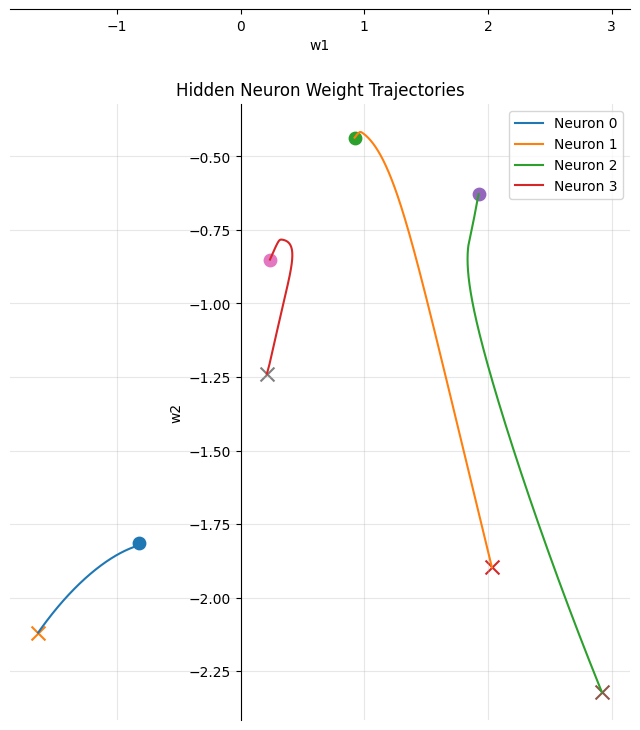

In [ ]:
import torch
import matplotlib.pyplot as plt

history = torch.stack(xor.w1_track)

plt.figure(figsize=(8,8))

for neuron in range(4):

    x_coord = history[:, 0, neuron]
    y_coord = history[:, 1, neuron]

    plt.plot(
        x_coord,
        y_coord,
        label=f"Neuron {neuron}"
    )

    # starting point
    plt.scatter(
        x_coord[0],
        y_coord[0],
        marker='o',
        s=80
    )

    # ending point
    plt.scatter(
        x_coord[-1],
        y_coord[-1],
        marker='x',
        s=100
    )

ax = plt.gca()

ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')

ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

ax.grid(True, alpha=0.3)

plt.legend()
plt.title("Hidden Neuron Weight Trajectories")
plt.xlabel("w1")
plt.ylabel("w2")

plt.show()

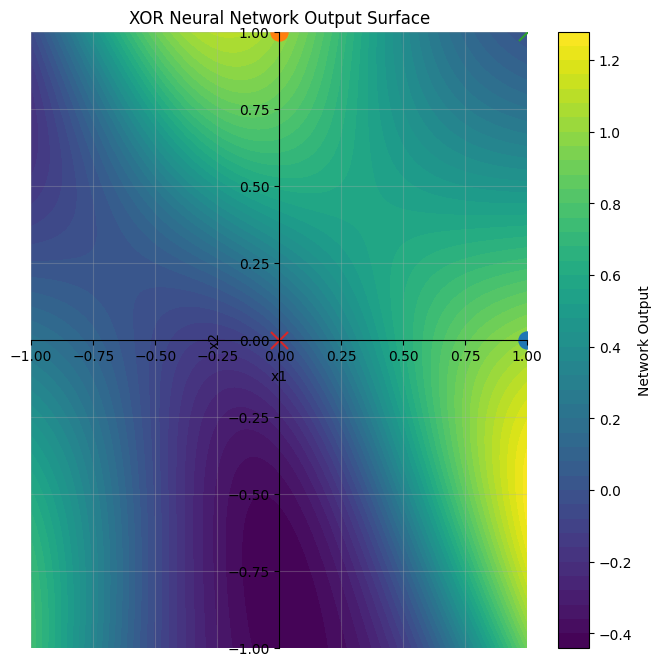

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Create Grid
# ==========================
resolution = 400

x_vals = np.linspace(-1, 1, resolution)
y_vals = np.linspace(-1, 1, resolution)

xx, yy = np.meshgrid(x_vals, y_vals)

points = np.stack(
    [xx.ravel(), yy.ravel()],
    axis=1
)

points_tensor = torch.tensor(
    points,
    dtype=torch.float32
)

# ==========================
# Network Predictions
# ==========================
with torch.no_grad():
    preds = xor.forward(points_tensor)

preds = preds.numpy().reshape(
    resolution,
    resolution
)

# ==========================
# Plot
# ==========================
plt.figure(figsize=(8,8))

contour = plt.contourf(
    xx,
    yy,
    preds,
    levels=50
)

plt.colorbar(contour, label="Network Output")

# ==========================
# Training Points
# ==========================
train_x = np.array([
    [1,0],
    [0,1],
    [1,1],
    [0,0]
])

train_y = np.array([
    1,
    1,
    0,
    0
])

for point, label in zip(train_x, train_y):

    if label == 1:
        plt.scatter(
            point[0],
            point[1],
            s=150,
            marker='o'
        )
    else:
        plt.scatter(
            point[0],
            point[1],
            s=150,
            marker='x'
        )

# ==========================
# Axes Through Origin
# ==========================
ax = plt.gca()

ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')

ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# ==========================
# Formatting
# ==========================
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)

ax.grid(True, alpha=0.3)

plt.title("XOR Neural Network Output Surface")
plt.xlabel("x1")
plt.ylabel("x2")

plt.show()